Warning there are missing values in your data !


100%|██████████| 100/100 [33:42<00:00, 20.23s/it]


16 attributes confirmed important: ['own_car_age', 'ext_source_2', 'amt_goods_price', 'ext_source_3', 'amt_annuity', 'occupation_type', 'ext_source_1', 'days_id_publish', 'ext_2_x_3', 'days_birth', 'code_gender', 'ext_source_mean', 'kui_ratio', 'education_type_Higher education', 'credit_duration', 'ratio_good_credit']
127 attributes confirmed unimportant: ['organization_type_Industry: type 11', 'obs_30_cnt_social_circle', 'organization_type_Restaurant', 'documents_count', 'flag_live_region_not_work', 'wallsmaterial_mode', 'organization_type_Services', 'organization_type_Insurance', 'organization_type_School', 'organization_type_Business Entity Type 1', 'fondkapremont_mode', 'amt_req_credit_breau_week', 'organization_type_Transport: type 2', 'organization_type_Business Entity Type 2', 'hour_apply_start', 'amt_req_credit_breau_year', 'flag_email', 'flag_document_5', 'organization_type_Self-employed', 'organization_type_Military', 'organization_type_Trade: type 3', 'flag_city_not_work', '

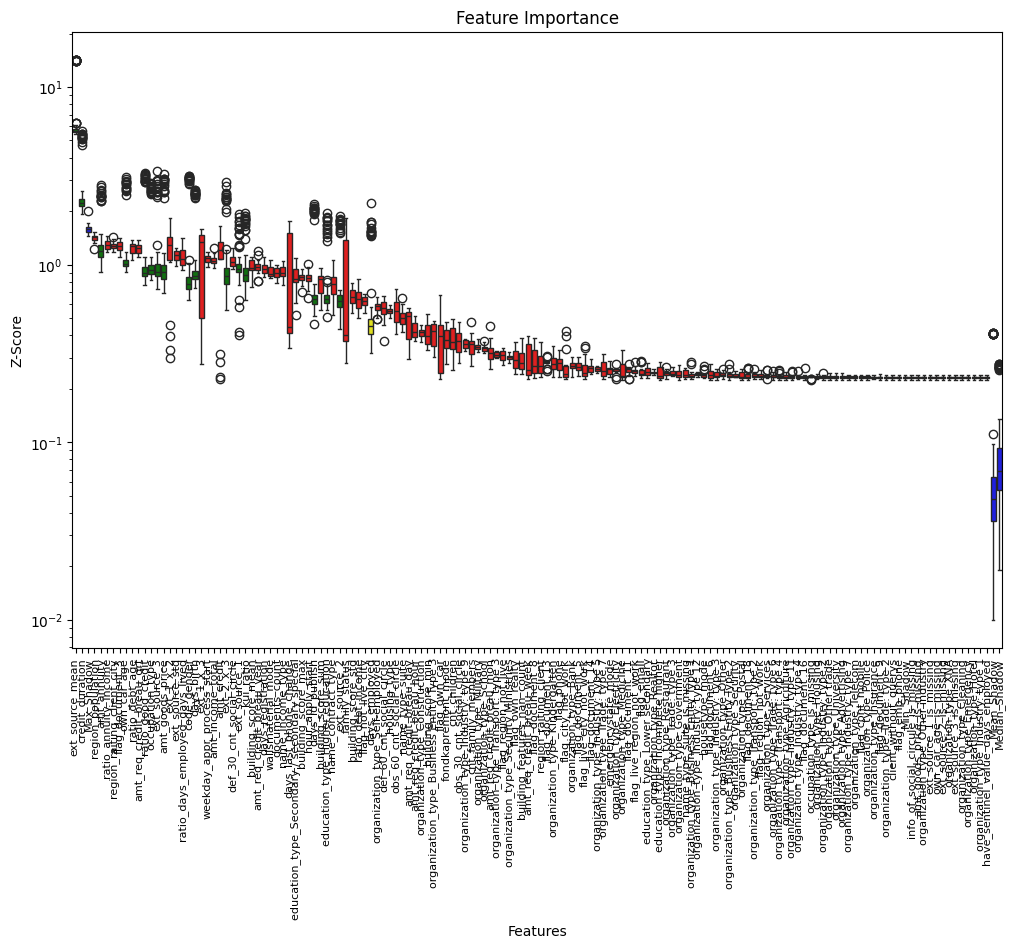

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn as skt
import xgboost as xgb
import scipy.stats
import json
from pandas.api.types import ( is_numeric_dtype, is_categorical_dtype, is_object_dtype, is_datetime64_any_dtype )
from default_risk.scripts.cv_mlfow_integration import run_cv_tracked_mlflow
import default_risk.config as cfg
import os
import xgboost as xgb
from dotenv import load_dotenv
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import mlflow
import mlflow.xgboost
from default_risk.scripts.auxiliars_for_modeling import cast_object_into_categoricals
from default_risk.scripts.auxiliars_for_modeling import get_baseline_setup
from default_risk.scripts.auxiliars_for_modeling import prepare_columns
import dtale
from BorutaShap import BorutaShap
import gc

cleaned_application_train= pd.read_parquet(cfg.PROCESSED_DIR / "application_train_with_kui.parquet")
X,Y = prepare_columns(cleaned_application_train)
X= cast_object_into_categoricals(X)

cv , hiperparams = get_baseline_setup() 
model = xgb.XGBClassifier(**hiperparams)
feat_selector = BorutaShap(importance_measure='shap', model=model, classification=True,pvalue=0.015)

feat_selector.fit(X=X, y=Y, n_trials=100, sample=False,
            	     train_or_test = 'test', normalize=True,
		     verbose=True)
subset = feat_selector.Subset()
aceptadas = feat_selector.accepted
rechazadas = feat_selector.rejected
tentativas = feat_selector.tentative
print('aceptadas')
print(aceptadas)
print('rechazadas')
print(rechazadas)
print('no se')
print(tentativas)
feat_selector.plot(which_features='all')


